### Introduction
This notebook applies a SARIMAX model to forecast Alberta Internal Load (AIL).

<class 'pandas.Series'>
DatetimeIndex: 36 entries, 2023-01-31 to 2025-12-31
Freq: ME
Series name: Actual AIL
Non-Null Count  Dtype
--------------  -----
36 non-null     int64
dtypes: int64(1)
memory usage: 576.0 bytes
None
Date
2023-01-31    7727633
2023-02-28    7027742
2023-03-31    7597838
2023-04-30    6758335
2023-05-31    6735129
Freq: ME, Name: Actual AIL, dtype: int64


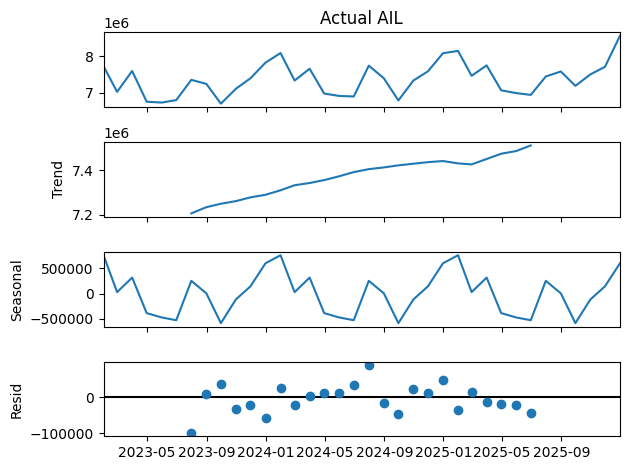

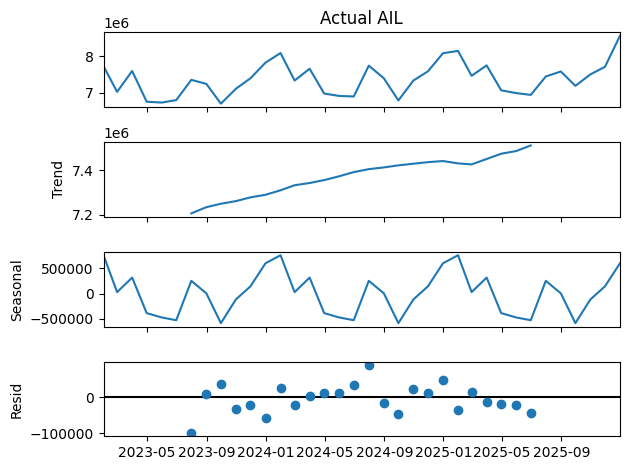

In [126]:
# Demand forecast
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

################### Load Data #####################################
df = pd.read_csv('2023ActualForecastData.csv')
df1 = pd.read_csv('2024ActualForecastData.csv')
df2 = pd.read_csv('2025ActualForecastData.csv')
AIL = pd.concat([df, df1, df2])
AIL['Date'] = pd.to_datetime(AIL['Date'])
AIL_indexed = AIL.set_index('Date')
demand_data = AIL_indexed['Actual AIL'].resample('ME').sum() # create time series
print(demand_data.info())
print(demand_data.head())

# Decompose time series into trend, seasonal and residual component
result = seasonal_decompose(demand_data, model='additive', period=12)
result.plot()


#### Stationary Check (ADF test)
ADF tests the null hypothesis that there is the existence of a unit root in the time series sample.
The presence of a unit root implies that the time series is non-stationary, that is,
its statistical properties such as mean and variance change over time and the series
follows a stochastic trend rather than reverting to a fixed mean.

In [127]:
def adftest(dataset):
    try:
        result = adfuller(dataset, autolag='AIC')
        if result[1] < 0.05:
            print('Time Series is Stationary')
        else:
            print('Fail to reject null hypothesis. Time Series is Non-Stationary')
    except Exception as e:
        print(f'Invalid dataset: {e}')

adftest(demand_data)

Time Series is Stationary


#### Differencing
Differencing is a method used to transform a non-stationary time series by calculating
the difference between consecutive observations.

$$y'_t = y_t - y_{t-1}$$

It stabilizes the mean of a time series by removing changes in level and trend,
making it more suitable for modelling.

Time Series is already stationary, no differencing needed


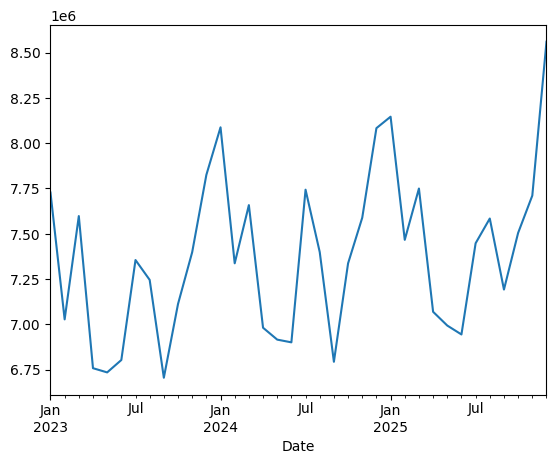

In [128]:
def adftest(dataset):
    try:
        result = adfuller(dataset, autolag='AIC')
        return result[1] < 0.05  # return True if stationary
    except Exception as e:
        print(f'Invalid dataset: {e}')
        return None

def difference(dataset, interval=1):
    if adftest(dataset):  # if stationary, skip
        print('Time Series is already stationary, no differencing needed')
        return dataset
    diff = []
    for i in range(interval, len(dataset)):
        diff.append(dataset.iloc[i] - dataset.iloc[i - interval])
    return pd.Series(diff)

difference(demand_data).plot()
plt.show()

#### Model Parameters
**Autocorrelation function (ACF):** Measures the correlation between the past values (lagged values) and the current value, including indirect effects. We will use the ACF to find Moving Average parameter q.

**Partial Autocorrelation function (PACF):** Measures the direct correlation between the k-th lagged value and the current value, removing indirect effects. We will use the PACF to find the Autoregressive parameter p.

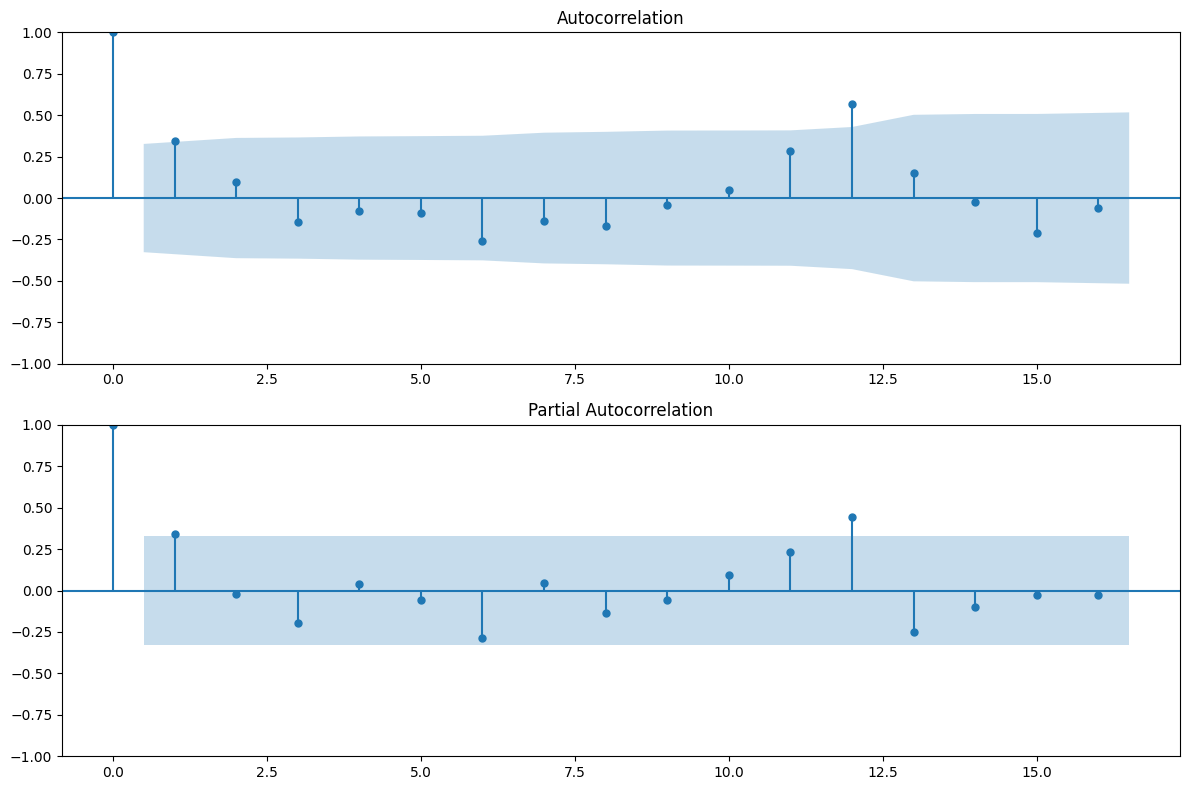

In [129]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(demand_data, ax=ax[0])   # 168 = one week of hours

plot_pacf(demand_data, ax=ax[1])  # 168 = one week of hours

plt.tight_layout()
plt.show()


### SARIMAX Model

                                     SARIMAX Results                                      
Dep. Variable:                         Actual AIL   No. Observations:                   28
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -401.524
Date:                            Thu, 07 May 2026   AIC                            813.048
Time:                                    12:41:46   BIC                            819.709
Sample:                                01-31-2023   HQIC                           815.084
                                     - 04-30-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9956      0.037     27.005      0.000       0.923       1.068
ma.L1         -0.4641      0.703   

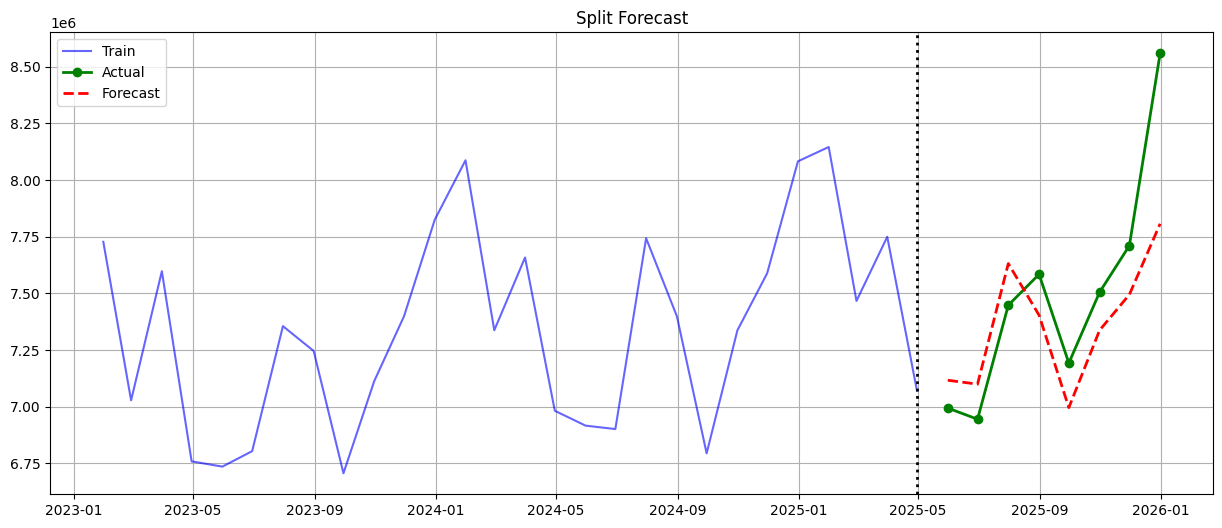


MAE: 246,930 MW
RMSE: 313,371 MW


In [131]:
# A function to split data for training and testing
def split_point(data, trainSize):
    """
    :param data: Time Series
    :param trainSize: Training set size proportion ie 80% of series is used for training
    :return: train data, test data
    """
    split_ind = int(len(data) * trainSize)
    train = data[:split_ind]
    test = data[split_ind:]
    return train, test

train , test = split_point(demand_data, 0.80)
train = train.asfreq('ME')
test = test.asfreq('ME')

model = SARIMAX(train,
            order=(1, 0, 1),
            seasonal_order=(1, 0, 1, 12))

model_fit = model.fit()
print(model_fit.summary())

forecast1 = model_fit.forecast(steps=len(test))
forecast1.index = test.index

# Plot
plt.figure(figsize=(15, 6))
plt.plot(train.index[-60:], train.values[-60:], 'b-', label='Train', alpha=0.6)
plt.plot(test.index, test.values, 'go-', label='Actual', linewidth=2)
plt.plot(forecast1.index, forecast1.values, 'r--', label='Forecast', linewidth=2)
plt.axvline(train.index[-1], color='black', linestyle=':', linewidth=2)
plt.legend()
plt.title('Split Forecast')
plt.grid(True)
plt.show()

# AIC most commonly refers to the Akaike Information Criterion, a statistical metric used to compare,
# select, and evaluate the quality of models based on their goodness of fit and simplicity.
# Lower AIC values indicate a better-fitting model with fewer variables.

# Accuracy
print(f"\nMAE: {mean_absolute_error(test, forecast1):,.0f} MW")
print(f"RMSE: {np.sqrt(mean_squared_error(test, forecast1)):,.0f} MW")

### Conclusion
This SARIMAX model can only capture one seasonal period at a time, that is, it cannot simultaneously model the daily, weekly, and annual cycles present in the AIL data. Moreover, the 3-year dataset is insufficient for reliable SARIMAX modelling at any frequency. Monthly (s=12) performed best out of the frequencies tested. With only 28 training observations, the seasonal parameters are insignificant as shown in the results table. Adding more could potentially improve this model's performance. Weekly (s=52) and daily (s=365) are computationally expensive, but do not necessarily perform better.